# 컨볼루션 신경망
## 강아지 vs 고양이

In [17]:
path = '../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/'

# train 데이터 폴더 정의
train_cats_dir = path + 'cats_and_dogs_filtered/train/cats/'
train_dogs_dir = path + 'cats_and_dogs_filtered/train/dogs/'

# validation 데이터 폴더 정의
val_cats_dir = path + 'cats_and_dogs_filtered/validation/cats/'
val_dogs_dir = path + 'cats_and_dogs_filtered/validation/dogs/'

print(f"train_cats_dir : {train_cats_dir}\ntrain_dogs_dir : {train_dogs_dir}")
print(f"val_cats_dir : {val_cats_dir}\ntrain_dogs_dir : {val_dogs_dir}")

train_cats_dir : ../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/
train_dogs_dir : ../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/cats_and_dogs_filtered/train/dogs/
val_cats_dir : ../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/cats_and_dogs_filtered/validation/cats/
train_dogs_dir : ../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/cats_and_dogs_filtered/validation/dogs/


In [20]:
import os

train_cats_fnames = os.listdir(train_cats_dir)
train_dogs_fnames = os.listdir(train_dogs_dir)

print(train_cats_fnames[:5])
print(train_dogs_fnames[:5])


['cat.463.jpg', 'cat.71.jpg', 'cat.460.jpg', 'cat.818.jpg', 'cat.992.jpg']
['dog.496.jpg', 'dog.342.jpg', 'dog.219.jpg', 'dog.312.jpg', 'dog.184.jpg']


In [21]:
val_cats_fnames = os.listdir(val_cats_dir)
val_dogs_fnames = os.listdir(val_dogs_dir)

print(val_cats_fnames[:5])
print(val_dogs_fnames[:5])

['cat.2256.jpg', 'cat.2066.jpg', 'cat.2429.jpg', 'cat.2104.jpg', 'cat.2272.jpg']
['dog.2283.jpg', 'dog.2317.jpg', 'dog.2110.jpg', 'dog.2469.jpg', 'dog.2056.jpg']


In [22]:
print(f'학습데이터 - cat: {len(train_cats_fnames)}, dog: {len(train_dogs_fnames)}')
print(f'검증데이터 - cat: {len(val_cats_fnames)}, dog: {len(val_dogs_fnames)}')

학습데이터 - cat: 1000, dog: 1000
검증데이터 - cat: 500, dog: 500


- 실제 데이터 시각화

['../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/cat.211.jpg', '../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/cat.669.jpg', '../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/cat.128.jpg', '../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/cat.749.jpg', '../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/cat.96.jpg', '../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/cat.422.jpg', '../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/cat.261.jpg', '../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/cats_and_dogs_filtered/train/cats/cat.663.jpg']
['../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/cats_and_dogs_filtered/cats_and_dogs_filtered/train/dogs/dog.728.jpg', '../교육 자료/2주차/02. CNN & 컴퓨터 비전/data/

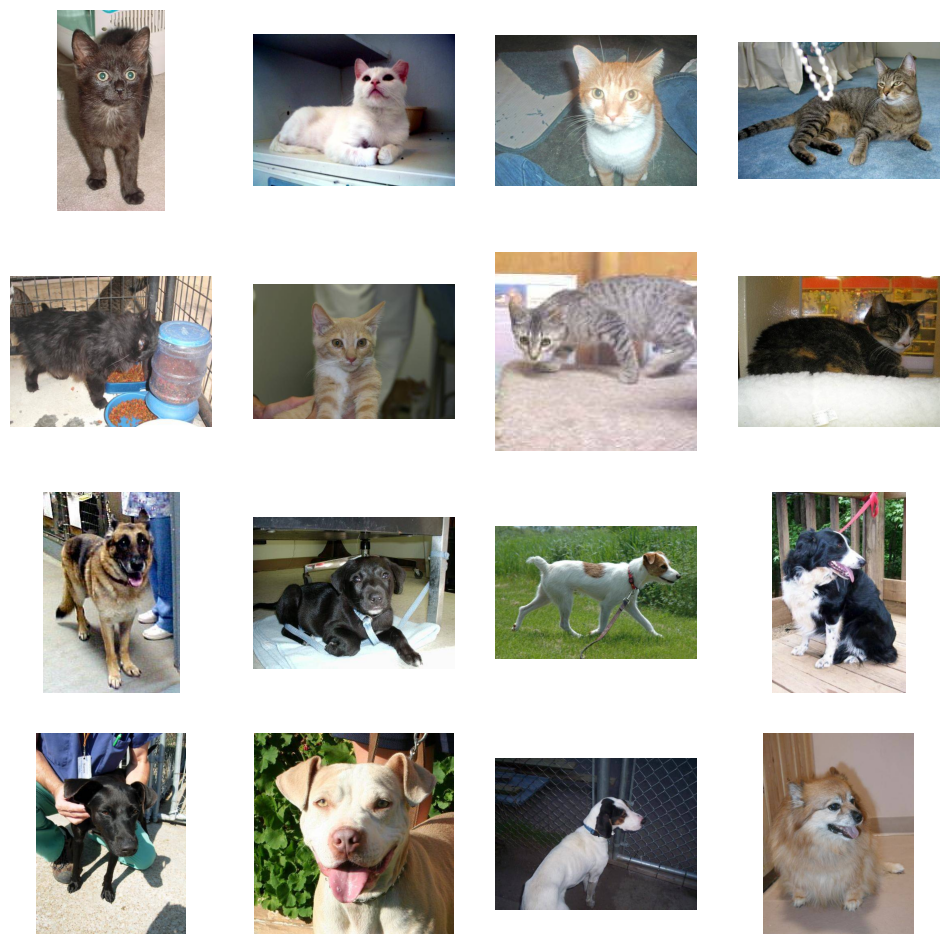

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

nrows, ncols = 4, 4  # 출력 행/열 개수 정의
pic_index = 0

fig = plt.gcf()
fig.set_size_inches(ncols*3, nrows*3)

pic_index += 108 

next_cats_pix = [ os.path.join(train_cats_dir, fname)  
                 for fname in train_cats_fnames[pic_index-8:pic_index]]

next_dogs_pix = [ os.path.join(train_dogs_dir, fname)  
                 for fname in train_dogs_fnames[pic_index-8:pic_index]]

print(next_cats_pix)
print(next_dogs_pix)

for i, img_path in enumerate(next_cats_pix + next_dogs_pix):
    axs = plt.subplot(nrows, ncols, i+1)   # 4행/4열의 이미지 출력
    axs.axis('off')   # 눈금선 제거

    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 이미지 픽셀을 0-1 사이의 값으로 스케일 조정
img_datagen = ImageDataGenerator(rescale = 1./255)

# 이미지 제너레이터 적용
train_generator = img_datagen.flow_from_directory(
  path + 'cats_and_dogs_filtered/train/',   # 학습 이미지 저장 폴더
  batch_size=20,                       # 모델에 전달한 이미지 개수(배치크기)
  target_size=(150, 150),              # 이미지 사이즈(리사이즈)
  class_mode='binary'                  # 이진 분류(cat vs dos, 0 또는 1)
  )

validation_generator = img_datagen.flow_from_directory(
  path + 'cats_and_dogs_filtered/validation/',   # 학습 이미지 저장 폴더
  batch_size=20,                       # 모델에 전달한 이미지 개수(배치크기)
  target_size=(150, 150),              # 이미지 사이즈(리사이즈)
  class_mode='binary'                  # 이진 분류(cat vs dos, 0 또는 1)
  )

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


# 모델구성

In [26]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Dense, Flatten
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.models import Sequential

model = Sequential()
# 이미지 사이즈 150 * 150 / 컬러라서 RGB 3개의 채널
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPool2D((2, 2), padding='same'))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/home/siwonl0508/ENTER/envs/deepl_tensor/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1784621132.152166  433883 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


- 모델 확인하기

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,654,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,895,553 (11.05 MB)

 Trainable params: 2,895,553 (11.05 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# 이진분류
model.compile(loss = 'binary_crossentropy',
              optimizer = Adam(0.05),
              metrics = ['acc'])

In [46]:
# 스템값 계산
def get_step(train_len, batch_size):
    if(train_len % batch_size > 0):
        return train_len // batch_size + 1
    else:
        return train_len // batch_size

- Batch size  
한 번에 모델에 넣어서 학습시키는 데이터의 크기  
현재는 전체 2000장인데 한번의 배치마다 32개씩 넣어서 학습 시킴 -> 이후에 가중치 업데이트  
  
- Steps_per_epoch  
1번의 epoch 동안 batch를 몇 번 반복해서 넣을 것인가

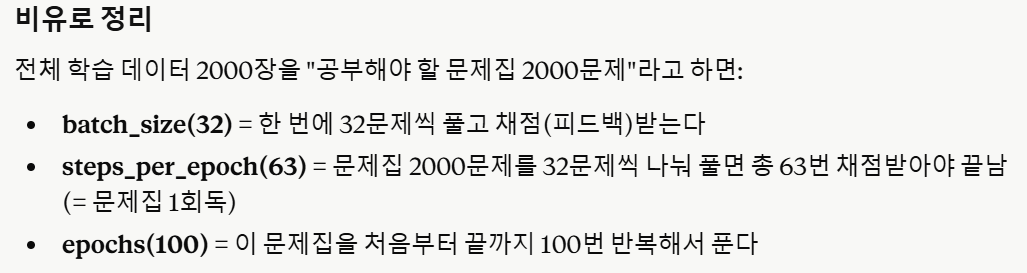

In [47]:
history = model.fit(train_generator,                     # 학습 데이터
                    steps_per_epoch=get_step(2000, 32),  # 한 epoch당 베치 반복 횟수
                    epochs=100,                           # 전체 학습 반복 횟수
                    validation_data=validation_generator,# 검증 데이터 
                    validation_steps=50)                 # 검증 데이터 반복 횟수

Epoch 1/100


I0000 00:00:1784622636.876761  441721 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_93111__.48


63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - acc: 0.4881 - loss: 17.7304 - val_acc: 0.5000 - val_loss: 0.6935
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.4730 - loss: 0.6952 - val_acc: 0.5000 - val_loss: 0.6932
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.5119 - loss: 0.6938 - val_acc: 0.5000 - val_loss: 0.6949
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.4797 - loss: 0.6968 - val_acc: 0.5000 - val_loss: 0.6937
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.4778 - loss: 0.6939 - val_acc: 0.5000 - val_loss: 0.6933
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.4973 - loss: 0.6951 - val_acc: 0.5000 - val_loss: 0.6962
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.4881 - loss: 0.6973 - val_acc: 0.5000 - val_loss: 0.6933
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.4770 - loss: 0.6939 - val_acc: 0.5000 - val_loss: 0.6931
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - acc: 0.5127 -

- 학습과정 그려보기

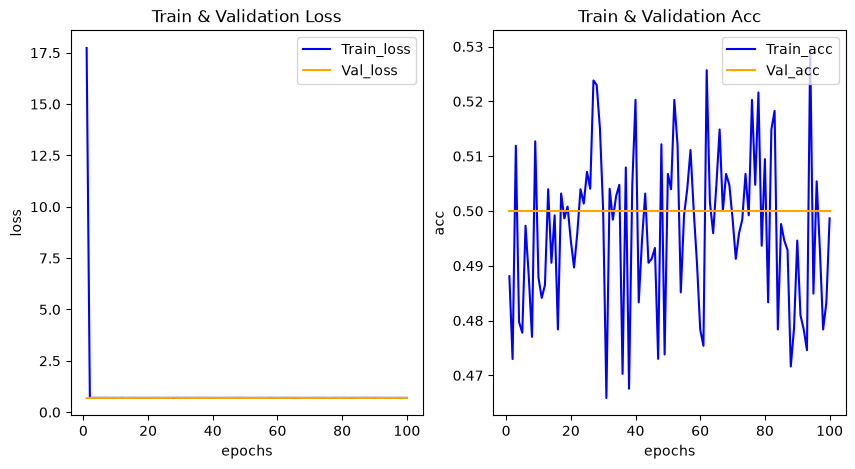

In [48]:
import matplotlib.pyplot as plt
his_data = history.history

loss = his_data['loss']
val_loss = his_data['val_loss']

epochs = range(1, len(loss)+1)

fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실율(lossl)
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color='blue', label='Train_loss')
ax1.plot(epochs, val_loss, color='orange', label='Val_loss')
ax1.set_title('Train & Validation Loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

# 훈련 및 검증 정확도
acc = his_data['acc']
val_acc = his_data['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color='blue', label='Train_acc')
ax2.plot(epochs, val_acc, color='orange', label='Val_acc')
ax2.set_title('Train & Validation Acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

- 학습 모델 저장

In [51]:
if not os.path.exists('./models'):
  os.mkdir('./models')

model.save('./models/cat_dog_model2.keras') 

# 모델 테스트

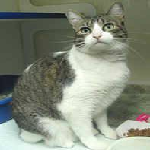

In [52]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(path + 'cats_and_dogs_filtered/validation/cats/cat.2024.jpg',
                     target_size=(150, 150))
img

In [53]:
img_arr = image.img_to_array(img)

print(img_arr)

[[[108. 116.  92.]
  [108. 116.  92.]
  [108. 116.  92.]
  ...
  [102. 106.  83.]
  [110. 114.  91.]
  [112. 116.  93.]]

 [[108. 116.  92.]
  [108. 116.  92.]
  [108. 116.  92.]
  ...
  [106. 110.  87.]
  [114. 118.  95.]
  [117. 121.  98.]]

 [[108. 116.  92.]
  [108. 116.  92.]
  [108. 116.  92.]
  ...
  [108. 112.  89.]
  [118. 122.  99.]
  [121. 125. 102.]]

 ...

 [[218. 240. 238.]
  [218. 240. 238.]
  [220. 242. 240.]
  ...
  [209. 225. 198.]
  [209. 225. 198.]
  [209. 225. 198.]]

 [[218. 240. 238.]
  [218. 240. 238.]
  [220. 242. 240.]
  ...
  [209. 225. 198.]
  [209. 225. 198.]
  [209. 225. 198.]]

 [[218. 240. 238.]
  [218. 240. 238.]
  [220. 242. 240.]
  ...
  [209. 225. 198.]
  [209. 225. 198.]
  [209. 225. 198.]]]


In [54]:
# 학습시 사용한 데이터 차원과 동일하게 변경(2000, 150, 150, 3)
# 3차원(150, 150, 3) => 4차원 변경((1. 150, 150, 3))
print(f'변경전:{img_arr.shape}')
img_arr_dims = np.expand_dims(img_arr, axis=0)
print(f'변경후:{img_arr_dims.shape}')

변경전:(150, 150, 3)
변경후:(1, 150, 150, 3)


In [ ]:
pred = model.predict(img_arr_dims)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([[0.52174807]], dtype=float32)